# Objectif 

Fichiers preprocessés :

* Données de positions : acouplane_pos.nc
* Données de pression : acouplane_raw_pressure.nc

Date de création : 05/10/2026

In [1]:
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy.io import loadmat
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

In [2]:
ROOT_PROGRAM = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd"
sys.path.append(ROOT_PROGRAM)
from publication.publication_figure import set_subfigures_abc_labels, color
from real_data_analysis.acouplane.src.acouplane_cst import *
from real_data_analysis.acouplane.src.acouplane_utils import *

# Données de position

## Chargement des données 

In [3]:
ds_pos = xr.open_dataset(ACOUPLANE_POSITIONS_NC_FPATH)
print(ds_pos)

<xarray.Dataset> Size: 525MB
Dimensions:         (rcv_id: 7, atl_datetime: 563739, mmsi: 526,
                     ais_datetime: 60447, src_datetime: 33608)
Coordinates:
  * rcv_id          (rcv_id) <U4 112B 'OBS1' 'OBS2' 'OBS4' ... 'OBS7' 'TLQ'
  * atl_datetime    (atl_datetime) datetime64[ns] 5MB 2026-02-24 ... 2026-03-...
  * ais_datetime    (ais_datetime) datetime64[ns] 484kB 2026-02-23T23:59:50 ....
  * src_datetime    (src_datetime) datetime64[ns] 269kB 2026-02-24T20:14:06.6...
Dimensions without coordinates: mmsi
Data variables:
    rcv_lon         (rcv_id) float64 56B ...
    rcv_lat         (rcv_id) float64 56B ...
    atl_lon         (atl_datetime) float64 5MB ...
    atl_lat         (atl_datetime) float64 5MB ...
    ais_lon         (mmsi, ais_datetime) float64 254MB ...
    ais_lat         (mmsi, ais_datetime) float64 254MB ...
    tir_SEGD        (src_datetime) int64 269kB ...
    tir_ECOS        (src_datetime) int64 269kB ...
    tir_src_lon     (src_datetime) float64 269

### Trajectoire ATALANTE

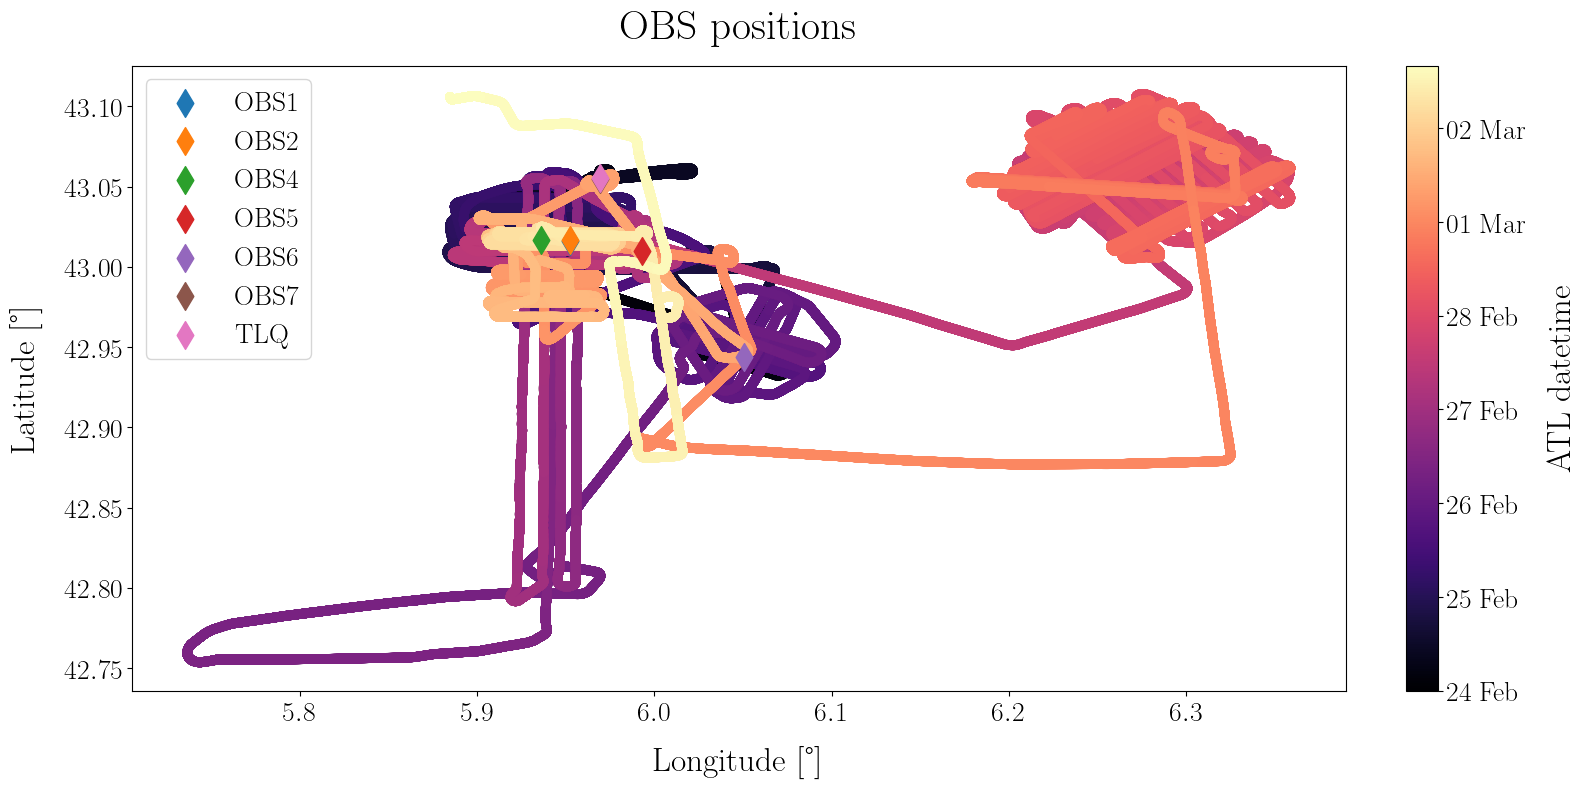

In [4]:
fig, ax = plt.subplots()

dates = ds_pos.atl_datetime.values
date_num = mdates.date2num(dates)

sc = ax.scatter(
    ds_pos.atl_lon,
    ds_pos.atl_lat,
    c=date_num,
    cmap="magma",
)

plot_obs_pos(ds_pos, ax=ax)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("ATL datetime")
cbar.ax.yaxis.set_major_locator(mdates.DayLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

## Positions des tirs sismiques 

### Positions tout au long de la campagne 

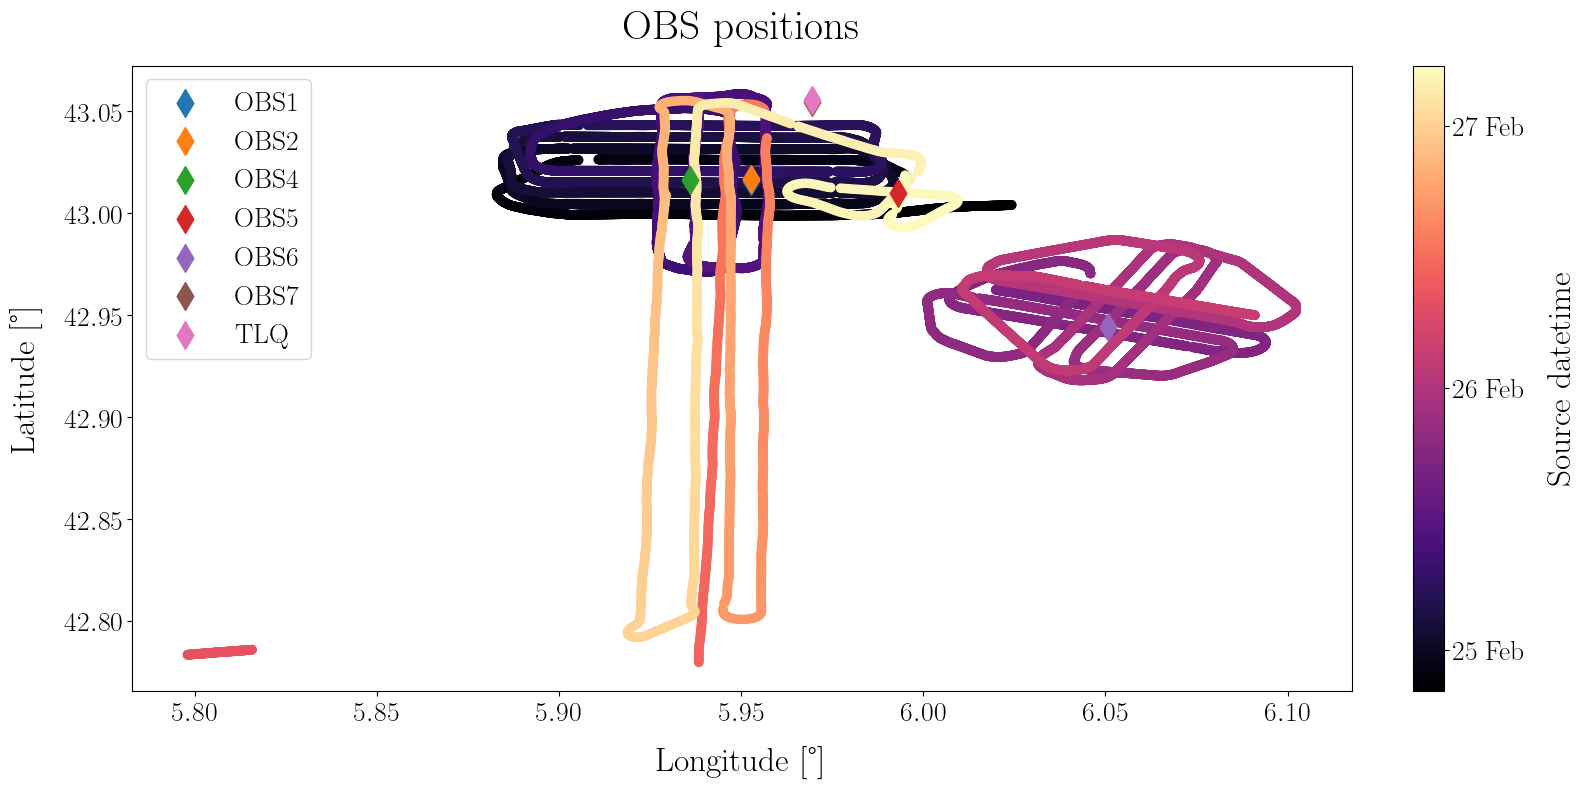

In [5]:
fig, ax = plt.subplots()

dates = ds_pos.src_datetime.values
date_num = mdates.date2num(dates)

sc = ax.scatter(
    ds_pos.tir_src_lon,
    ds_pos.tir_src_lat,
    c=date_num,
    cmap="magma",
)

plot_obs_pos(ds_pos, ax=ax)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Source datetime")
cbar.ax.yaxis.set_major_locator(mdates.DayLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

### Zoom sur le réseau de capteurs 

La zone est quadrillée de manière adéquate pour la mise en œuvre de la méthode de localisation. 

Les transects du large vers la côte sont effectués deux jours plus tard (le 27/02) et devrait permettre de tester la résilience de la librairie de réplique sur une courte période (2 jours).  

(42.91618571428571, 43.11618571428571)

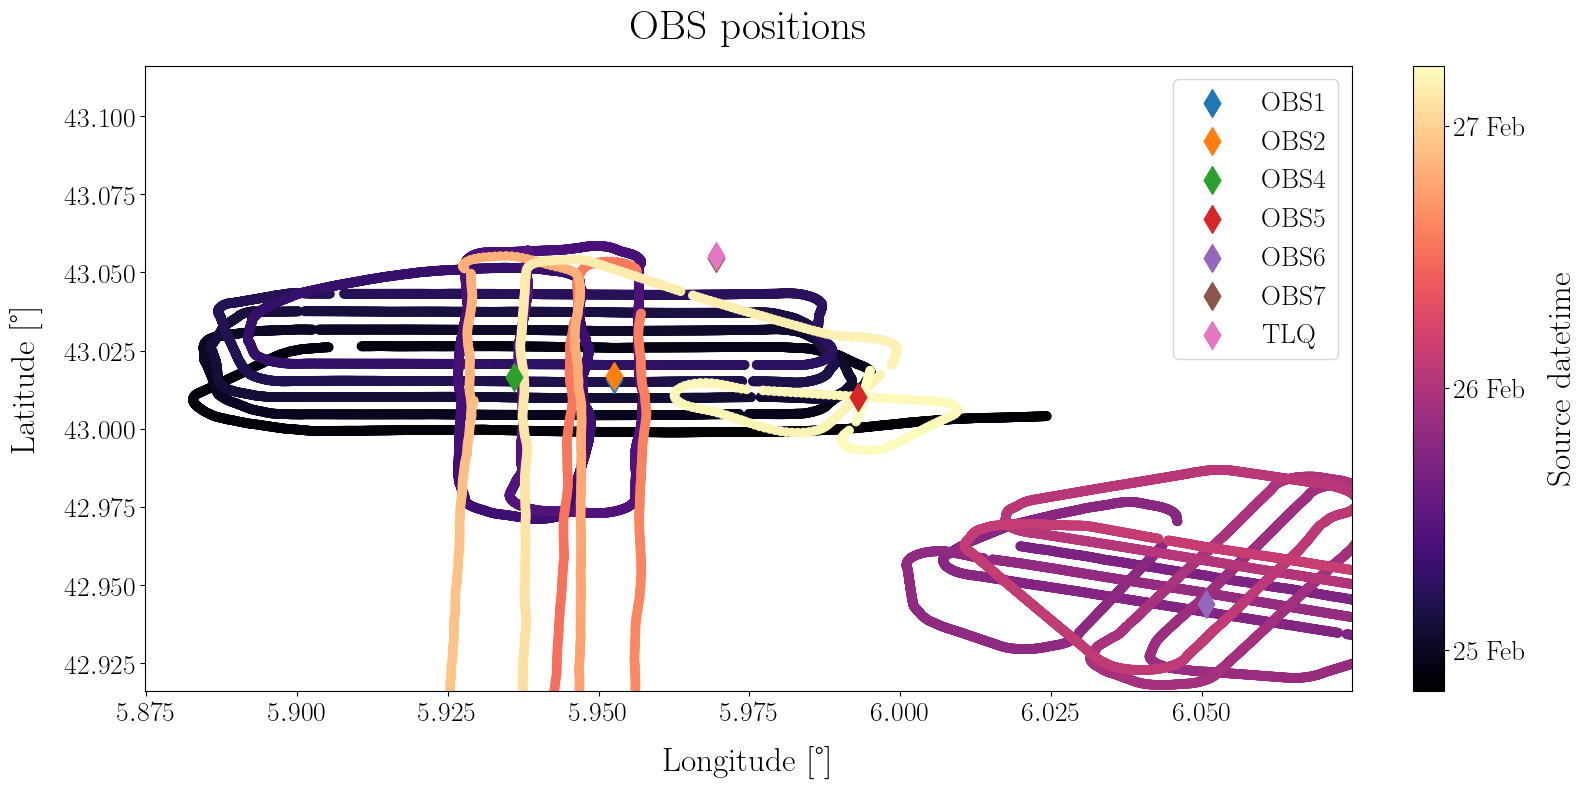

In [6]:
fig, ax = plt.subplots()

dates = ds_pos.src_datetime.values
date_num = mdates.date2num(dates)

sc = ax.scatter(
    ds_pos.tir_src_lon,
    ds_pos.tir_src_lat,
    c=date_num,
    cmap="magma",
)

plot_obs_pos(ds_pos, ax=ax)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Source datetime")
cbar.ax.yaxis.set_major_locator(mdates.DayLocator())
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

ax.set_xlim((ds_pos.rcv_lon.mean() - 0.1, ds_pos.rcv_lon.mean() + 0.1))
ax.set_ylim((ds_pos.rcv_lat.mean() - 0.1, ds_pos.rcv_lat.mean() + 0.1))

### Trajectoire par jours 

La journée la plus propice est la journée du 25/02. 

Pour mémoire l'extrait de donnée étudié avant le transfert du jeu de données complet était le 24/02 autour de 22h00. 

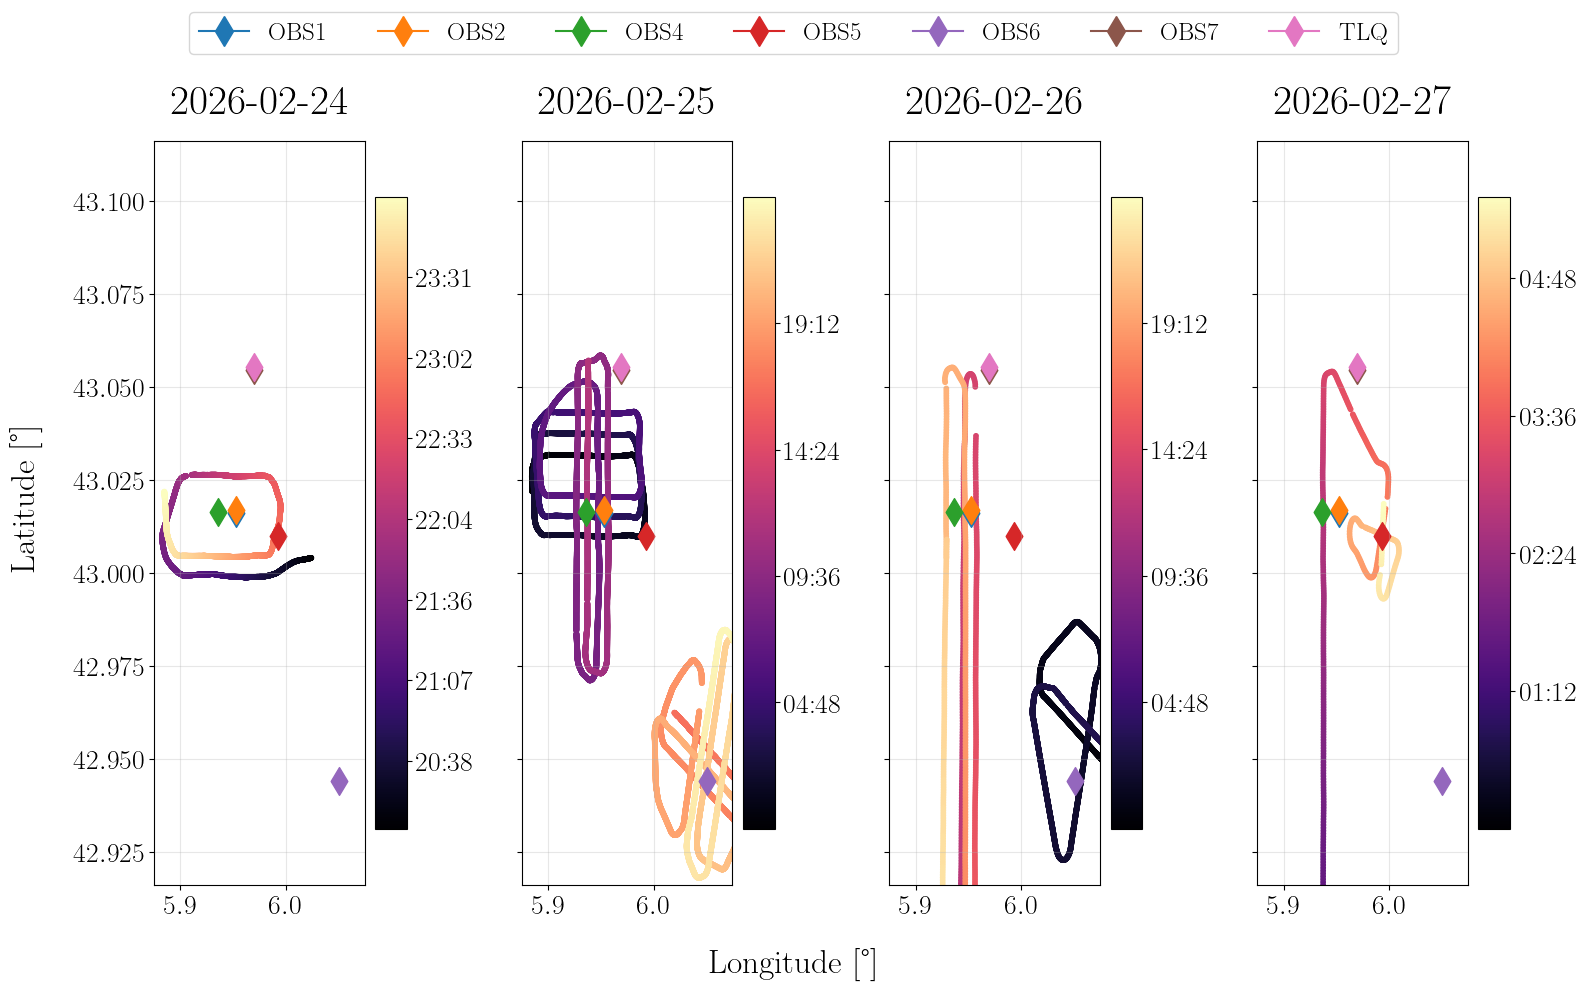

In [7]:
dates = pd.to_datetime(ds_pos.src_datetime.values)
days = dates.normalize().unique()

fig, axes = plt.subplots(
    nrows=1, ncols=len(days), figsize=(16, 10), sharey=True, sharex=True
)

for ax, day in zip(axes, days):

    mask = dates.normalize() == day
    ds_day = ds_pos.isel(src_datetime=mask)

    # Convert time to Matplotlib numerical dates
    date_num = mdates.date2num(pd.to_datetime(ds_day.src_datetime.values))

    sc = ax.scatter(
        ds_day.tir_src_lon,
        ds_day.tir_src_lat,
        c=date_num,
        cmap="magma",
        s=10,
    )

    plot_obs_pos(ds_day, ax=ax, add_legend=False, add_title=False)

    ax.set_title(day.strftime("%Y-%m-%d"))
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, alpha=0.3)

    # Time colorbar for this day
    cbar = fig.colorbar(sc, ax=ax)
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    # cbar.set_label("Time")

ax.set_xlim((ds_pos.rcv_lon.mean() - 0.1, ds_pos.rcv_lon.mean() + 0.1))
ax.set_ylim((ds_pos.rcv_lat.mean() - 0.1, ds_pos.rcv_lat.mean() + 0.1))
fig.supxlabel("Longitude [°]")
fig.supylabel("Latitude [°]")

legend_handles = []
for i, id in enumerate(ds_pos.rcv_id.values):
    legend_handles.append(
        Line2D([0], [0], color=f"C{i}", marker="d", label=id, markersize=15)
    )
fig.legend(handles=legend_handles, loc="outside upper center", ncols=len(legend_handles), fontsize=18)

# Données de pression

## Chargement des données 

In [8]:
ds_pressure = xr.open_dataset(ACOUPLANE_PRESSURE_NC_FPATH)

## Example de chargement des données à partir de ce fichier 

Les données stockées sont les données raw, il faut donc les convertir et fabriquer le vecteur de temps.

In [9]:
# Convert to volts
ds_pressure = convert_raw_pressure_to_physical_units(ds_pressure=ds_pressure)

In [10]:
ds_pressure

<xarray.Dataset> Size: 2GB
Dimensions:         (time_obs1: 100014000, time_obs2: 100034000, obs_id: 2)
Coordinates:
  * obs_id          (obs_id) <U4 32B 'obs1' 'obs2'
Dimensions without coordinates: time_obs1, time_obs2
Data variables:
    pressure_obs1   (time_obs1) float64 800MB 0.03867 0.02945 ... 0.0566 0.05001
    pressure_obs2   (time_obs2) float64 800MB 0.02267 0.0273 ... 0.03432 0.03432
    start_datetime  (obs_id) datetime64[ns] 16B ...
Attributes:
    description:  Données de pression (voie hydro 3)
    campagne:     ACOUPLANE
    fs:           2000
    fullscale:    4.52

In [11]:
# Build a vector of datetime for each OBS signal
obs_datetimes = build_obs_datetime_vector(ds_pressure=ds_pressure)

In [12]:
# Slice the dataset to a specific time range
start_dt = datetime(2026, 2, 25, 4, 0, 0)
stop_dt = datetime(2026, 2, 25, 5, 0, 0)

obs1_slice_idx = (
    np.where(obs_datetimes["obs1"] >= start_dt)[0][0],
    np.where(obs_datetimes["obs1"] <= stop_dt)[0][-1],
)
obs2_slice_idx = (
    np.where(obs_datetimes["obs2"] >= start_dt)[0][0],
    np.where(obs_datetimes["obs2"] <= stop_dt)[0][-1],
)
pressure_slice = ds_pressure.isel(
    time_obs1=slice(
        obs1_slice_idx[0],
        obs1_slice_idx[1] + 1,
    ),
    time_obs2=slice(obs2_slice_idx[0], obs2_slice_idx[1] + 1),
)
pressure_slice["time_obs1"] = obs_datetimes["obs1"][
    obs1_slice_idx[0] : obs1_slice_idx[1] + 1
]
pressure_slice["time_obs2"] = obs_datetimes["obs2"][
    obs2_slice_idx[0] : obs2_slice_idx[1] + 1
]
pressure_slice["time_obs1"].attrs = {"unit": "UTC", "long_name": "Time"}
pressure_slice["time_obs2"].attrs = {"unit": "UTC", "long_name": "Time"}

IndexError: index 0 is out of bounds for axis 0 with size 0

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


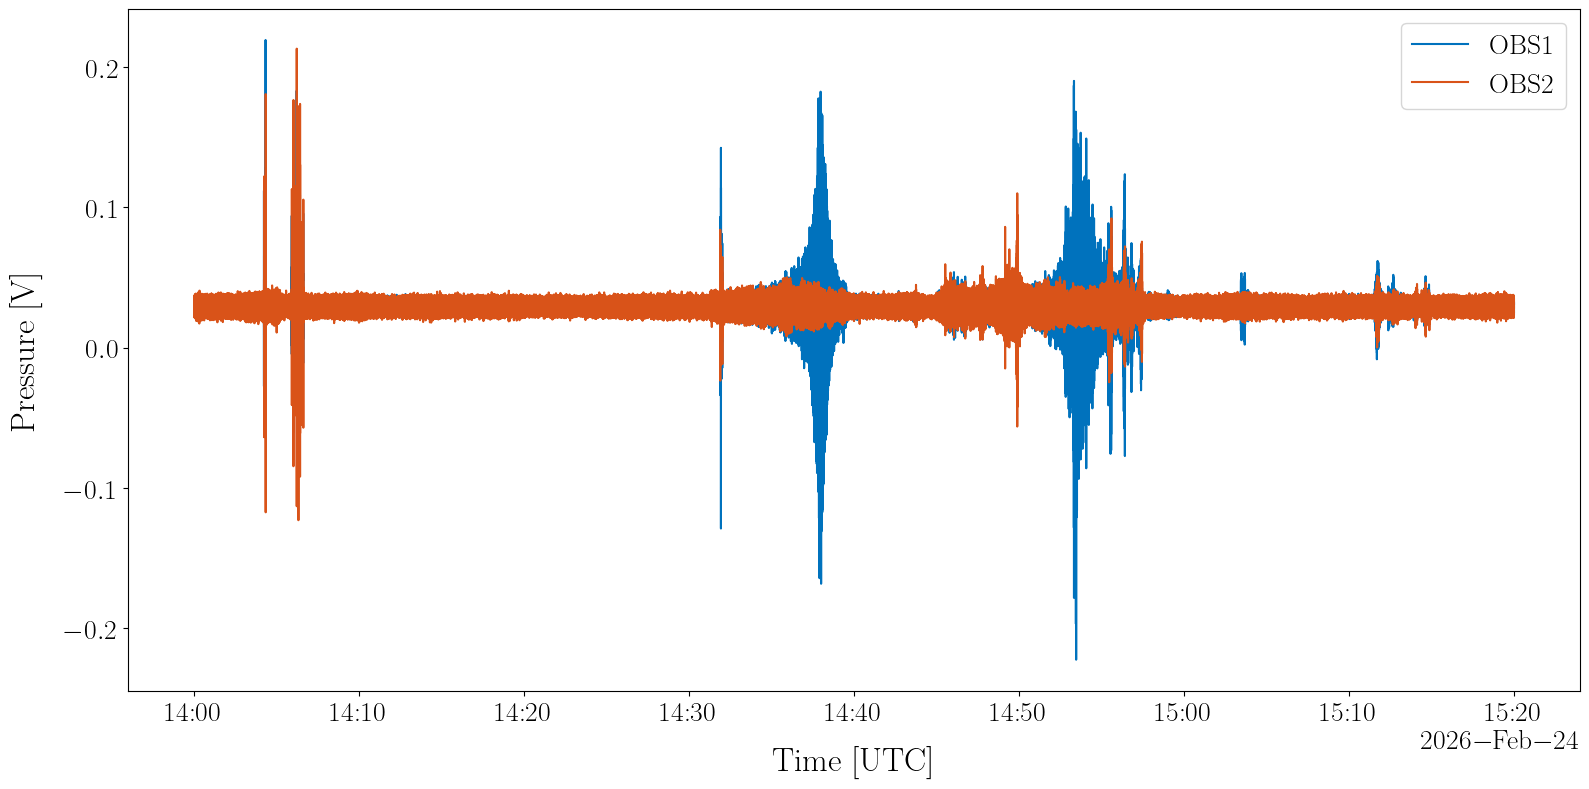

In [ ]:
plt.figure()
pressure_slice.pressure_obs1.plot(label="OBS1", color=color(0))
pressure_slice.pressure_obs2.plot(label="OBS2", color=color(1))
plt.legend()